In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix

In [20]:
data_income=pd.read_csv("income(1).csv",na_values=[" ?"])

In [21]:
data=data_income.copy()

In [22]:
data.head()

,age,JobType,EdType,maritalstatus,occupation,relationship,race,gender,capitalgain,capitalloss,hoursperweek,nativecountry,SalStat
0,45,Private,HS-grad,Divorced,Adm-clerical,Not-in-family,White,Female,0,0,28,United-States,"less than or equal to 50,000"
1,24,Federal-gov,HS-grad,Never-married,Armed-Forces,Own-child,White,Male,0,0,40,United-States,"less than or equal to 50,000"
2,44,Private,Some-college,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,"greater than 50,000"
3,27,Private,9th,Never-married,Craft-repair,Other-relative,White,Male,0,0,40,Mexico,"less than or equal to 50,000"
4,20,Private,Some-college,Never-married,Sales,Not-in-family,White,Male,0,0,35,United-States,"less than or equal to 50,000"


In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31978 entries, 0 to 31977
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   age            31978 non-null  int64 
 1   JobType        30169 non-null  object
 2   EdType         31978 non-null  object
 3   maritalstatus  31978 non-null  object
 4   occupation     30162 non-null  object
 5   relationship   31978 non-null  object
 6   race           31978 non-null  object
 7   gender         31978 non-null  object
 8   capitalgain    31978 non-null  int64 
 9   capitalloss    31978 non-null  int64 
 10  hoursperweek   31978 non-null  int64 
 11  nativecountry  31978 non-null  object
 12  SalStat        31978 non-null  object
dtypes: int64(4), object(9)
memory usage: 3.2+ MB


In [24]:
data["race"].unique()

array([' White', ' Black', ' Amer-Indian-Eskimo', ' Asian-Pac-Islander',
       ' Other'], dtype=object)

In [25]:
data.isnull().sum()

age                 0
JobType          1809
EdType              0
maritalstatus       0
occupation       1816
relationship        0
race                0
gender              0
capitalgain         0
capitalloss         0
hoursperweek        0
nativecountry       0
SalStat             0
dtype: int64

In [26]:
data["age"].unique()

array([45, 24, 44, 27, 20, 51, 17, 19, 60, 40, 30, 38, 23, 32, 54, 50, 37,
       52, 49, 22, 35, 67, 46, 33, 43, 28, 41, 25, 63, 59, 34, 26, 72, 62,
       58, 47, 39, 53, 57, 21, 42, 74, 36, 29, 31, 69, 18, 65, 55, 48, 71,
       70, 66, 56, 61, 68, 64, 73, 81, 78, 76, 90, 88, 75, 77, 80, 82, 79,
       83, 84, 85, 86, 87])

In [27]:
data["SalStat"].unique()

array([' less than or equal to 50,000', ' greater than 50,000'],
      dtype=object)

In [28]:
data.describe()

,age,capitalgain,capitalloss,hoursperweek
count,31978.000000,31978.000000,31978.000000,31978.000000
mean,38.579023,1064.360623,86.739352,40.417850
std,13.662085,7298.596271,401.594301,12.345285
min,17.000000,0.000000,0.000000,1.000000
25%,28.000000,0.000000,0.000000,40.000000
50%,37.000000,0.000000,0.000000,40.000000
75%,48.000000,0.000000,0.000000,45.000000
max,90.000000,99999.000000,4356.000000,99.000000


In [29]:
data.columns

Index(['age', 'JobType', 'EdType', 'maritalstatus', 'occupation',
       'relationship', 'race', 'gender', 'capitalgain', 'capitalloss',
       'hoursperweek', 'nativecountry', 'SalStat'],
      dtype='object')

In [30]:
#converting race

In [31]:
data["JobType"].unique()

array([' Private', ' Federal-gov', nan, ' Self-emp-inc',
       ' Self-emp-not-inc', ' Local-gov', ' State-gov', ' Without-pay',
       ' Never-worked'], dtype=object)

In [33]:
summary_cate=data.describe(include="O")

In [34]:
summary_cate

,JobType,EdType,maritalstatus,occupation,relationship,race,gender,nativecountry,SalStat
count,30169,31978,31978,30162,31978,31978,31978,31978,31978
unique,8,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,"less than or equal to 50,000"
freq,22286,10368,14692,4038,12947,27430,21370,29170,24283


In [36]:
data["JobType"].value_counts()

JobType
Private             22286
Self-emp-not-inc     2499
Local-gov            2067
State-gov            1279
Self-emp-inc         1074
Federal-gov           943
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [38]:
data["occupation"].value_counts()

occupation
Prof-specialty       4038
Craft-repair         4030
Exec-managerial      3992
Adm-clerical         3721
Sales                3584
Other-service        3212
Machine-op-inspct    1966
Transport-moving     1572
Handlers-cleaners    1350
Farming-fishing       989
Tech-support          912
Protective-serv       644
Priv-house-serv       143
Armed-Forces            9
Name: count, dtype: int64

In [40]:
data["JobType"].unique()

array([' Private', ' Federal-gov', nan, ' Self-emp-inc',
       ' Self-emp-not-inc', ' Local-gov', ' State-gov', ' Without-pay',
       ' Never-worked'], dtype=object)

In [41]:
data["occupation"].unique()

array([' Adm-clerical', ' Armed-Forces', ' Prof-specialty',
       ' Craft-repair', ' Sales', ' Exec-managerial',
       ' Machine-op-inspct', nan, ' Transport-moving', ' Farming-fishing',
       ' Tech-support', ' Other-service', ' Handlers-cleaners',
       ' Protective-serv', ' Priv-house-serv'], dtype=object)

In [42]:
#Data preprocessing

In [44]:
data.isnull().sum()

age                 0
JobType          1809
EdType              0
maritalstatus       0
occupation       1816
relationship        0
race                0
gender              0
capitalgain         0
capitalloss         0
hoursperweek        0
nativecountry       0
SalStat             0
dtype: int64

In [56]:
missing=data[data.isnull().any(axis=1)]

In [57]:
missing.shape

(1816, 13)

In [58]:
data.shape

(31978, 13)

In [59]:
missing.shape

(1816, 13)

In [60]:
data2=data.dropna(axis=0)

In [63]:
data2.columns

Index(['age', 'JobType', 'EdType', 'maritalstatus', 'occupation',
       'relationship', 'race', 'gender', 'capitalgain', 'capitalloss',
       'hoursperweek', 'nativecountry', 'SalStat'],
      dtype='object')

In [66]:
data2=data2[["age","capitalgain","capitalloss","hoursperweek"]]

In [67]:
corr=data2.corr()

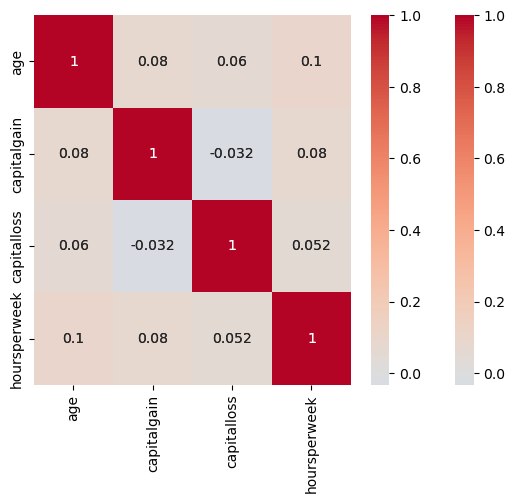

In [70]:
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.show()

In [71]:
data2=data.dropna(axis=0)

In [73]:
data2.columns

Index(['age', 'JobType', 'EdType', 'maritalstatus', 'occupation',
       'relationship', 'race', 'gender', 'capitalgain', 'capitalloss',
       'hoursperweek', 'nativecountry', 'SalStat'],
      dtype='object')

In [74]:
#Gender propoeriton table
pd.crosstab(index=data2["gender"],columns="count",normalize=True)

col_0,count
gender,
Female,0.324315
Male,0.675685


In [76]:
pd.crosstab(index=data2["gender"],columns=data2["SalStat"],normalize=True,margins=True)

SalStat,"greater than 50,000","less than or equal to 50,000",All
gender,,,
Female,0.036868,0.287448,0.324315
Male,0.212055,0.463630,0.675685
All,0.248922,0.751078,1.000000


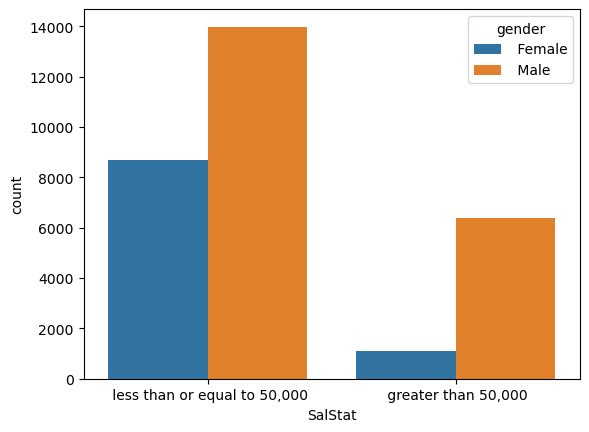

In [81]:
sns.countplot(x="SalStat", data=data2, hue="gender")
plt.show()

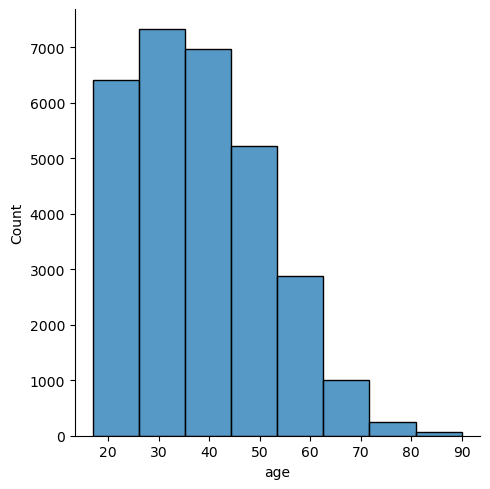

In [85]:
sns.displot(data2["age"],bins=8,kde=False)
plt.show()

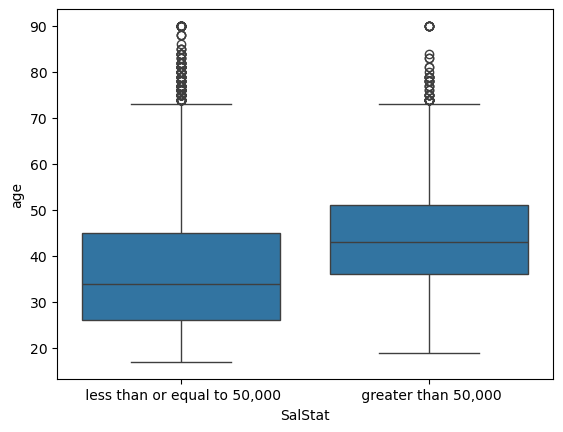

In [87]:
sns.boxplot(x="SalStat", y="age", data=data2)
plt.show()

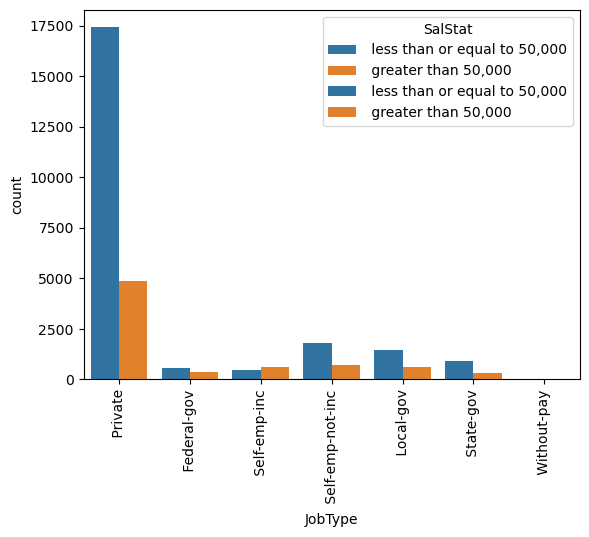

In [92]:
sns.countplot(x="JobType",data=data2, hue="SalStat")
plt.xticks(rotation=90)
plt.show()

In [94]:
data2.columns

Index(['age', 'JobType', 'EdType', 'maritalstatus', 'occupation',
       'relationship', 'race', 'gender', 'capitalgain', 'capitalloss',
       'hoursperweek', 'nativecountry', 'SalStat'],
      dtype='object')

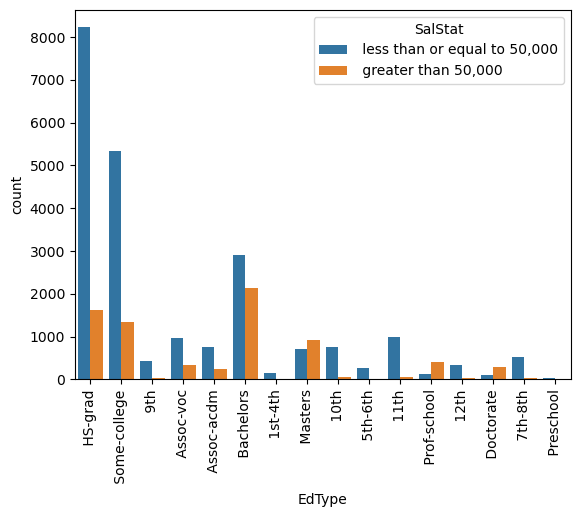

In [95]:
sns.countplot(x="EdType",data=data2, hue="SalStat")
plt.xticks(rotation=90)
plt.show()

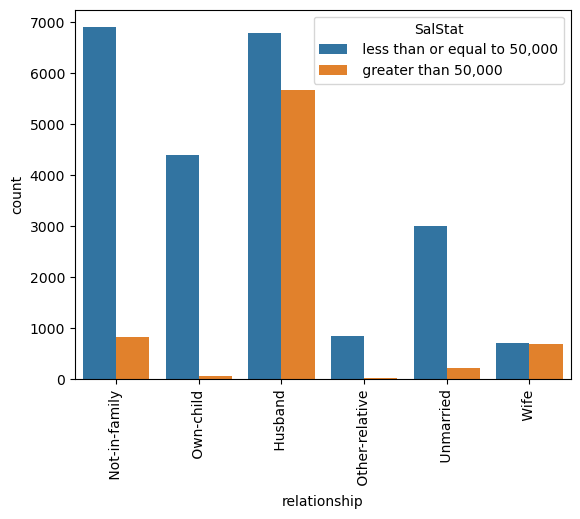

In [97]:
sns.countplot(x="relationship",data=data2, hue="SalStat")
plt.xticks(rotation=90)
plt.show()

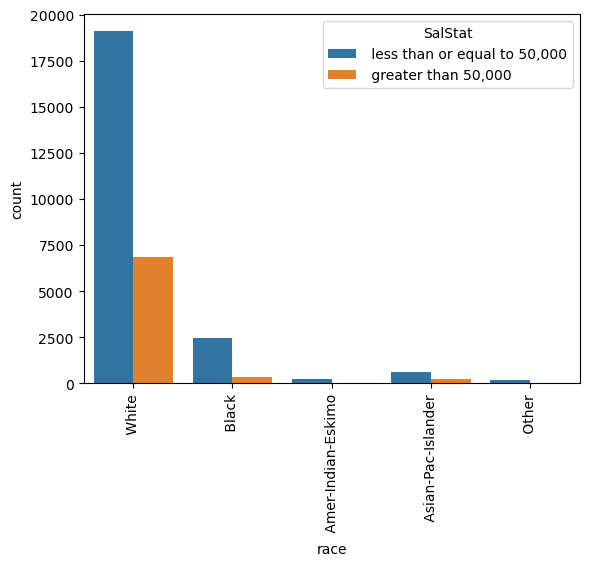

In [98]:
sns.countplot(x="race",data=data2, hue="SalStat")
plt.xticks(rotation=90)
plt.show()

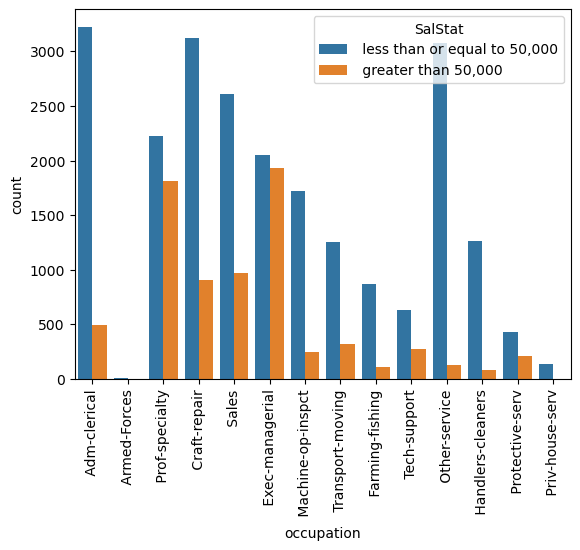

In [99]:
sns.countplot(x="occupation",data=data2, hue="SalStat")
plt.xticks(rotation=90)
plt.show()